# Heart Attack Prediction Using Machine Learning

## Project Overview

Heart disease remains one of the leading causes of death worldwide, making early identification of high-risk individuals an important public health objective. This project applies machine learning techniques to predict whether a patient is likely to experience a heart attack based on demographic, lifestyle, and medical information.

The project follows a complete end-to-end machine learning workflow, including data cleaning, exploratory data analysis (EDA), feature engineering, data preprocessing, model training, evaluation, hyperparameter tuning, and feature importance analysis.

Five classification algorithms were developed and compared:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- Linear Support Vector Classifier (LinearSVC)
- K-Nearest Neighbors (KNN)

Because the dataset is imbalanced, model performance is evaluated using Precision, Recall, F1-score, ROC AUC, Precision-Recall Curves, and Confusion Matrices rather than relying solely on accuracy. Hyperparameter tuning was then performed on the strongest baseline models to improve predictive performance and identify the most suitable model for heart attack prediction.

## Project Objectives

The objectives of this project are to:

- Explore and understand the healthcare dataset through exploratory data analysis.
- Clean and preprocess the data for machine learning.
- Build multiple classification models for heart attack prediction.
- Compare model performance using appropriate evaluation metrics.
- Improve model performance through hyperparameter tuning.
- Identify the most influential factors contributing to heart attack risk.
- Recommend the best-performing model for deployment.

## Dataset Description

The dataset contains demographic, lifestyle, and health-related information collected from over **246,000 individuals**.

It includes variables such as:

- Age
- Sex
- General Health
- BMI
- Smoking Status
- Physical Activity
- Diabetes
- Stroke History
- Angina
- Arthritis
- Kidney Disease
- Asthma
- Sleep Hours
- Alcohol Consumption
- Vaccination History
- Other medical conditions

The target variable is **HadHeartAttack**, indicating whether an individual has experienced a heart attack.

In [15]:
# ===============================
# Import Required Libraries
# ===============================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Data preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)
from sklearn.pipeline import Pipeline

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    classification_report
)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [16]:
#LOAD DATASET
heart_data = pd.read_csv("C:/Users/HomePC/Desktop/heart_2022_no_nans.csv")
heart_data

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,HadAngina,HadStroke,HadAsthma,HadSkinCancer,HadCOPD,HadDepressiveDisorder,HadKidneyDisease,HadArthritis,HadDiabetes,DeafOrHardOfHearing,BlindOrVisionDifficulty,DifficultyConcentrating,DifficultyWalking,DifficultyDressingBathing,DifficultyErrands,SmokerStatus,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AgeCategory,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,Very good,4.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,No,No,No,No,No,No,No,Yes,No,No,No,No,No,No,No,Former smoker,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",Age 65 to 69,1.60,71.67,27.99,No,No,Yes,Yes,"Yes, received Tdap",No,No
1,Alabama,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,6.0,None of them,No,No,No,No,No,No,No,No,Yes,Yes,No,No,No,No,No,No,Former smoker,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",Age 70 to 74,1.78,95.25,30.13,No,No,Yes,Yes,"Yes, received tetanus shot but not sure what type",No,No
2,Alabama,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,"6 or more, but not all",No,No,No,No,No,No,No,No,Yes,No,No,Yes,No,Yes,No,No,Former smoker,Never used e-cigarettes in my entire life,Yes,"White only, Non-Hispanic",Age 75 to 79,1.85,108.86,31.66,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes
3,Alabama,Female,Fair,5.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,No,No,No,Yes,No,Yes,No,Yes,No,No,No,No,Yes,No,No,Never smoked,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",Age 80 or older,1.70,90.72,31.32,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes
4,Alabama,Female,Good,3.0,15.0,Within past year (anytime less than 12 months ...,Yes,5.0,1 to 5,No,No,No,No,No,No,No,No,Yes,No,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",Age 80 or older,1.55,79.38,33.07,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246017,Virgin Islands,Male,Very good,0.0,0.0,Within past 2 years (1 year but less than 2 ye...,Yes,6.0,None of them,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",Age 60 to 64,1.78,102.06,32.28,Yes,No,No,No,"Yes, received tetanus shot but not sure what type",No,No
246018,Virgin Islands,Female,Fair,0.0,7.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,No,No,No,No,No,Yes,No,No,No,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,No,"Black only, Non-Hispanic",Age 25 to 29,1.93,90.72,24.34,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,Yes
246019,Virgin Islands,Male,Good,0.0,15.0,Within past year (anytime less than 12 months ...,Yes,7.0,1 to 5,No,No,Yes,No,No,No,No,No,Yes,Yes,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,No,"Multiracial, Non-Hispanic",Age 65 to 69,1.68,83.91,29.86,Yes,Yes,Yes,Yes,"Yes, received tetanus shot but not sure what type",No,Yes
246020,Virgin Islands,Female,Excellent,2.0,2.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,No,"Black only, Non-Hispanic",Age 50 to 54,1.70,83.01,28.66,No,Yes,Yes,No,"Yes, received tetanus shot but not sure what type",No,No


In [17]:
heart_data.info()
heart_data.describe()
heart_data.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 246022 entries, 0 to 246021
Data columns (total 40 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   State                      246022 non-null  str    
 1   Sex                        246022 non-null  str    
 2   GeneralHealth              246022 non-null  str    
 3   PhysicalHealthDays         246022 non-null  float64
 4   MentalHealthDays           246022 non-null  float64
 5   LastCheckupTime            246022 non-null  str    
 6   PhysicalActivities         246022 non-null  str    
 7   SleepHours                 246022 non-null  float64
 8   RemovedTeeth               246022 non-null  str    
 9   HadHeartAttack             246022 non-null  str    
 10  HadAngina                  246022 non-null  str    
 11  HadStroke                  246022 non-null  str    
 12  HadAsthma                  246022 non-null  str    
 13  HadSkinCancer              246022 non-nu

State                        0
Sex                          0
GeneralHealth                0
PhysicalHealthDays           0
MentalHealthDays             0
LastCheckupTime              0
PhysicalActivities           0
SleepHours                   0
RemovedTeeth                 0
HadHeartAttack               0
HadAngina                    0
HadStroke                    0
HadAsthma                    0
HadSkinCancer                0
HadCOPD                      0
HadDepressiveDisorder        0
HadKidneyDisease             0
HadArthritis                 0
HadDiabetes                  0
DeafOrHardOfHearing          0
BlindOrVisionDifficulty      0
DifficultyConcentrating      0
DifficultyWalking            0
DifficultyDressingBathing    0
DifficultyErrands            0
SmokerStatus                 0
ECigaretteUsage              0
ChestScan                    0
RaceEthnicityCategory        0
AgeCategory                  0
HeightInMeters               0
WeightInKilograms            0
BMI     

In [18]:
# Check for duplicate rows
duplicates = heart_data.duplicated()

# Count how many duplicates exist
print("Number of duplicate rows:", duplicates.sum())

# Display the duplicate rows (if any)
print("Duplicate rows:")
print(heart_data[duplicates])

# remove duplicates
heart_data = heart_data.drop_duplicates()
print("Shape after removing duplicates:", heart_data.shape)

Number of duplicate rows: 9
Duplicate rows:
               State     Sex GeneralHealth  PhysicalHealthDays  \
5702         Arizona  Female     Excellent                 0.0   
87555       Maryland  Female          Good                 0.0   
88402       Maryland    Male     Excellent                 0.0   
137645    New Jersey    Male          Good                 0.0   
174923  Rhode Island  Female     Very good                 0.0   
184137  South Dakota  Female          Fair                30.0   
208013       Vermont  Female     Very good                 0.0   
216362    Washington    Male     Excellent                 0.0   
225974    Washington    Male     Very good                 0.0   

        MentalHealthDays                                    LastCheckupTime  \
5702                 0.0  Within past year (anytime less than 12 months ...   
87555                0.0  Within past year (anytime less than 12 months ...   
88402                0.0  Within past year (anytime less t

In [19]:
for column in heart_data.columns:
    print(f"\n--- Value Counts for: {column} ---")
    print(heart_data[column].value_counts().head(20))


--- Value Counts for: State ---
State
Washington        14998
Maryland           9163
Minnesota          9161
Ohio               8995
New York           8923
Texas              7408
Florida            7315
Kansas             6145
Wisconsin          6126
Maine              6013
Iowa               5672
Hawaii             5596
Virginia           5565
Indiana            5502
South Carolina     5471
Massachusetts      5465
Arizona            5461
Utah               5373
Michigan           5370
Colorado           5159
Name: count, dtype: int64

--- Value Counts for: Sex ---
Sex
Female    127806
Male      118207
Name: count, dtype: int64

--- Value Counts for: GeneralHealth ---
GeneralHealth
Very good    86996
Good         77407
Excellent    41522
Fair         30658
Poor          9430
Name: count, dtype: int64

--- Value Counts for: PhysicalHealthDays ---
PhysicalHealthDays
0.0     152794
30.0     17159
2.0      14728
1.0      10058
3.0       9137
5.0       8939
10.0      6068
7.0       5221

Exploratory Data Analysis

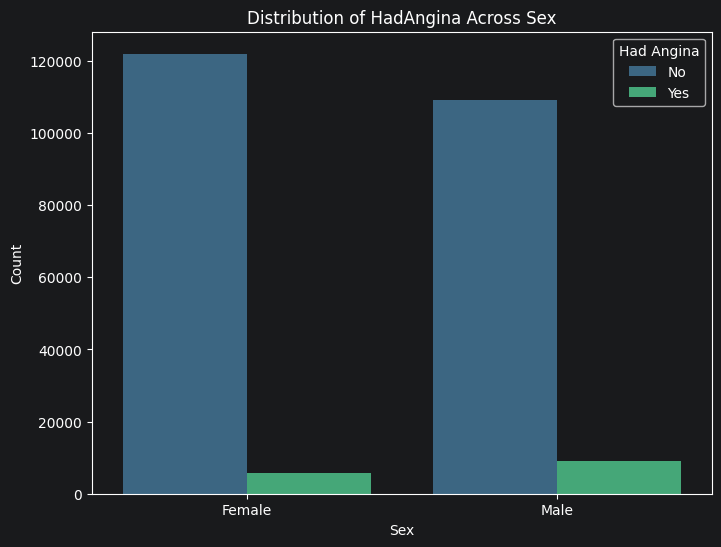

In [20]:
plt.figure(figsize=(8, 6))
sns.countplot(data=heart_data, x='Sex', hue='HadAngina', palette='viridis')

plt.legend(title='Had Angina', labels=['No', 'Yes'])
plt.title('Distribution of HadAngina Across Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

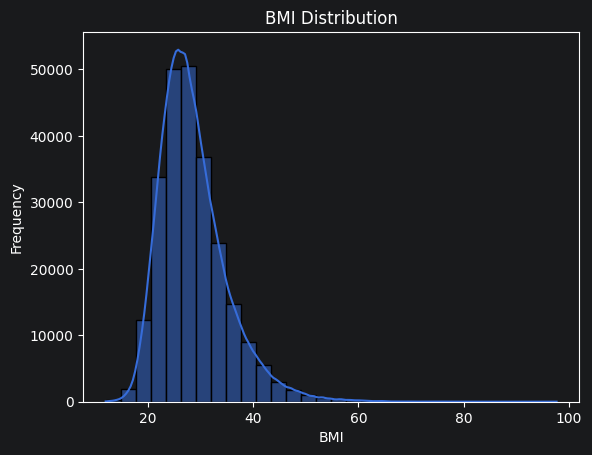

In [21]:
# BMI distribution
sns.histplot(heart_data["BMI"], bins=30, kde=True)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

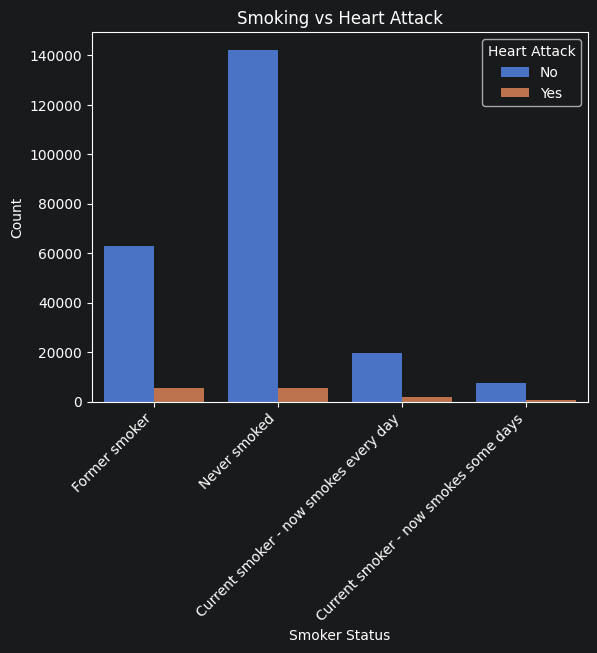

In [22]:
# Smoking vs Heart Attack
sns.countplot(x="SmokerStatus", hue="HadHeartAttack", data=heart_data)
plt.title("Smoking vs Heart Attack")
plt.xlabel("Smoker Status")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.legend(title='Heart Attack', labels=['No', 'Yes'])
plt.show()

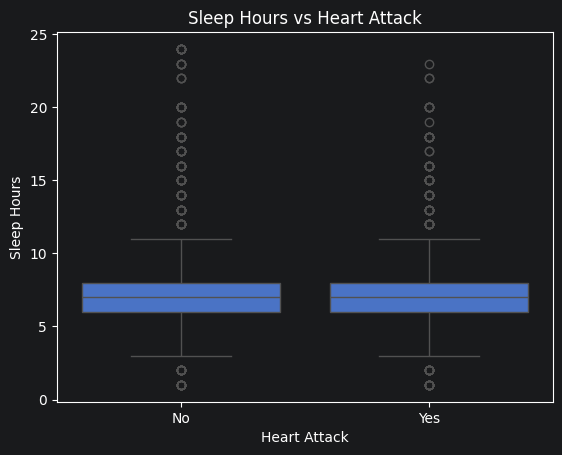

In [23]:
# Sleep Hours by Heart Attack Status
sns.boxplot(x="HadHeartAttack", y="SleepHours", data=heart_data)
plt.title("Sleep Hours vs Heart Attack")
plt.xlabel("Heart Attack")
plt.ylabel("Sleep Hours")
plt.show()


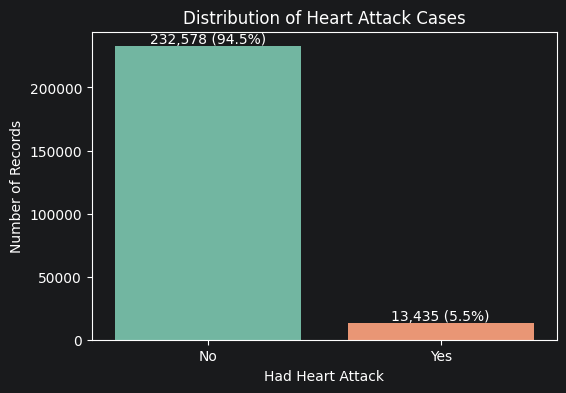

In [24]:
# Count values
counts = heart_data["HadHeartAttack"].value_counts()

# Plot
plt.figure(figsize=(6,4))
sns.barplot(
    x=counts.index,
    y=counts.values,
    palette="Set2"
)

# Add percentages on top of bars
for i, val in enumerate(counts.values):
    plt.text(i, val + 2000, f"{val:,} ({val/len(heart_data)*100:.1f}%)",
             ha='center', fontsize=10)

plt.title("Distribution of Heart Attack Cases")
plt.ylabel("Number of Records")
plt.xlabel("Had Heart Attack")
plt.show()


## Encoding Categorical Variables

In [25]:
binary_yn_cols = [
    "PhysicalActivities", "HadHeartAttack", "HadAngina", "HadStroke",
    "HadAsthma", "HadSkinCancer", "HadCOPD", "HadDepressiveDisorder",
    "HadKidneyDisease", "HadArthritis", "DeafOrHardOfHearing",
    "BlindOrVisionDifficulty", "DifficultyConcentrating", "DifficultyWalking",
    "DifficultyDressingBathing", "DifficultyErrands", "AlcoholDrinkers",
    "HIVTesting", "FluVaxLast12", "PneumoVaxEver", "HighRiskLastYear"
]

for col in binary_yn_cols:
    heart_data[col] = heart_data[col].map({
        "Yes": 1,
        "No": 0
    })

In [26]:
#sex
#heart_data["Sex"] = heart_data["Sex"].str.strip()
heart_data["Sex"] = heart_data["Sex"].map({
    "Male": 0,
    "Female": 1
})
heart_data["Sex"].value_counts()

Sex
1    127806
0    118207
Name: count, dtype: int64

In [27]:

health_map = {
    'Poor': 1,
    'Fair': 2,
    'Good': 3,
    'Very good': 4,
    'Excellent': 5
}

heart_data['GeneralHealth'] = heart_data['GeneralHealth'].map(health_map)


In [28]:
age_map = {
    'Age 18 to 24': 1,
    'Age 25 to 29': 2,
    'Age 30 to 34': 3,
    'Age 35 to 39': 4,
    'Age 40 to 44': 5,
    'Age 45 to 49': 6,
    'Age 50 to 54': 7,
    'Age 55 to 59': 8,
    'Age 60 to 64': 9,
    'Age 65 to 69': 10,
    'Age 70 to 74': 11,
    'Age 75 to 79': 12,
    'Age 80 or older': 13
}

heart_data['AgeCategory'] = heart_data['AgeCategory'].map(age_map)

In [29]:
checkup_map = {
    '5 or more years ago': 1,
    'Within past 5 years (2 years but less than 5 years ago)': 2,
    'Within past 2 years (1 year but less than 2 years ago)': 3,
    'Within past year (anytime less than 12 months ago)': 4
}

heart_data['LastCheckupTime'] = heart_data['LastCheckupTime'].map(checkup_map)

In [30]:
teeth_map = {
    'None of them': 0,
    '1 to 5': 1,
    '6 or more, but not all': 2,
    'All': 3
}

heart_data['RemovedTeeth'] = heart_data['RemovedTeeth'].map(teeth_map)

In [31]:
smoker_map = {'Never smoked': 0,
              'Former smoker': 1,
              'Current smoker - now smokes every day': 2,
              'Current smoker - now smokes some days': 3}

heart_data["SmokerStatus"] = heart_data["SmokerStatus"].map(smoker_map)

In [32]:
heart_data["SmokerStatus"].value_counts()

SmokerStatus
0    147731
1     68524
2     21659
3      8099
Name: count, dtype: int64

In [33]:
nominal_cols = [
    'State',
    'HadDiabetes',
    'ECigaretteUsage',
    'RaceEthnicityCategory',
    'TetanusLast10Tdap',
    'CovidPos',
    'ChestScan'
]

heart_data = pd.get_dummies(
    heart_data,
    columns=nominal_cols,
    drop_first=True,
    dtype=int
)

In [34]:
#heart_data.info()
heart_data["RemovedTeeth"].value_counts()

RemovedTeeth
0    131585
1     74701
2     25949
3     13778
Name: count, dtype: int64

In [35]:
heart_data.info()

<class 'pandas.DataFrame'>
Index: 246013 entries, 0 to 246021
Columns: 102 entries, Sex to ChestScan_Yes
dtypes: float64(6), int64(96)
memory usage: 193.3 MB


In [36]:
heart_data.head()

,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,HadAngina,HadStroke,HadAsthma,HadSkinCancer,HadCOPD,HadDepressiveDisorder,HadKidneyDisease,HadArthritis,DeafOrHardOfHearing,BlindOrVisionDifficulty,DifficultyConcentrating,DifficultyWalking,DifficultyDressingBathing,DifficultyErrands,SmokerStatus,AgeCategory,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,HighRiskLastYear,State_Alaska,State_Arizona,State_Arkansas,State_California,State_Colorado,State_Connecticut,State_Delaware,State_District of Columbia,State_Florida,State_Georgia,State_Guam,State_Hawaii,State_Idaho,State_Illinois,State_Indiana,State_Iowa,State_Kansas,State_Kentucky,State_Louisiana,State_Maine,State_Maryland,State_Massachusetts,State_Michigan,State_Minnesota,State_Mississippi,State_Missouri,State_Montana,State_Nebraska,State_Nevada,State_New Hampshire,State_New Jersey,State_New Mexico,State_New York,State_North Carolina,State_North Dakota,State_Ohio,State_Oklahoma,State_Oregon,State_Pennsylvania,State_Puerto Rico,State_Rhode Island,State_South Carolina,State_South Dakota,State_Tennessee,State_Texas,State_Utah,State_Vermont,State_Virgin Islands,State_Virginia,State_Washington,State_West Virginia,State_Wisconsin,State_Wyoming,"HadDiabetes_No, pre-diabetes or borderline diabetes",HadDiabetes_Yes,"HadDiabetes_Yes, but only during pregnancy (female)",ECigaretteUsage_Not at all (right now),ECigaretteUsage_Use them every day,ECigaretteUsage_Use them some days,RaceEthnicityCategory_Hispanic,"RaceEthnicityCategory_Multiracial, Non-Hispanic","RaceEthnicityCategory_Other race only, Non-Hispanic","RaceEthnicityCategory_White only, Non-Hispanic","TetanusLast10Tdap_Yes, received Tdap","TetanusLast10Tdap_Yes, received tetanus shot but not sure what type","TetanusLast10Tdap_Yes, received tetanus shot, but not Tdap",CovidPos_Tested positive using home test without a health professional,CovidPos_Yes,ChestScan_Yes
0,1,4,4.0,0.0,4,1,9.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,10,1.60,71.67,27.99,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0
1,0,4,0.0,0.0,4,1,6.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,11,1.78,95.25,30.13,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0
2,0,4,0.0,0.0,4,0,8.0,2,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,1,12,1.85,108.86,31.66,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1
3,1,2,5.0,0.0,4,1,9.0,0,0,0,0,0,1,0,1,0,1,0,0,0,1,0,0,0,13,1.70,90.72,31.32,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0
4,1,3,3.0,15.0,4,1,5.0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,13,1.55,79.38,33.07,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0


In [37]:
heart_data.select_dtypes(include=['object','string']).columns


Index([], dtype='str')

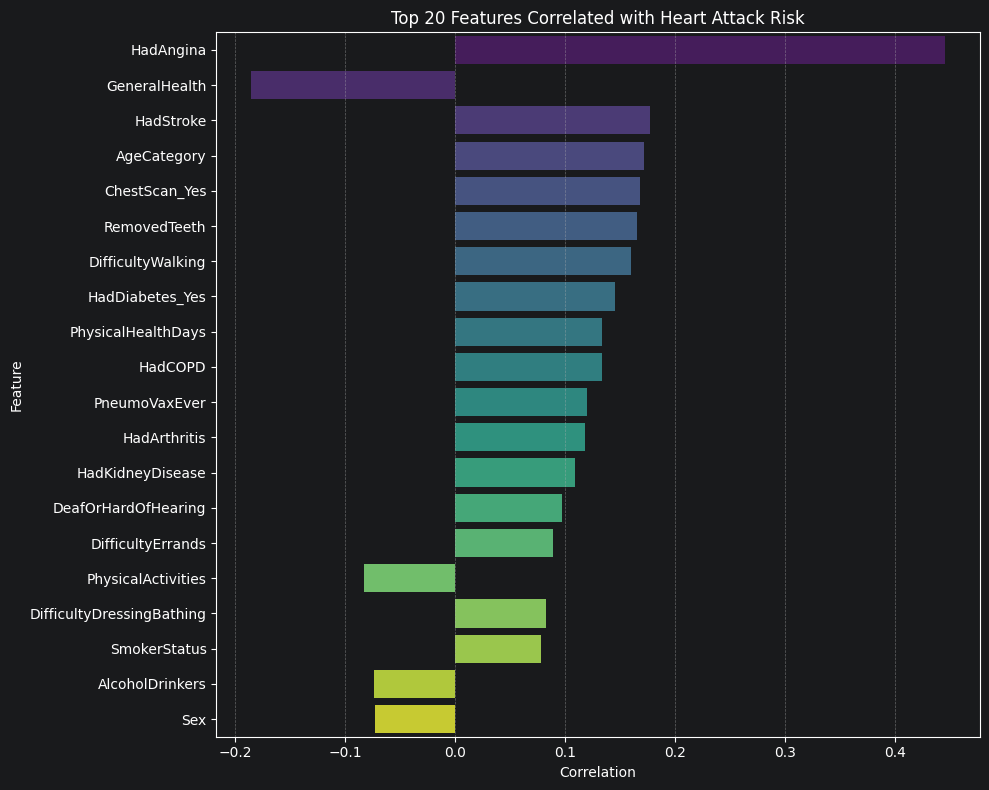

In [71]:
# Calculate correlations
correlations = heart_data.corr(numeric_only=True)['HadHeartAttack'].drop('HadHeartAttack')

# Top 20 positive and negative correlations
top_correlations = correlations.sort_values(key=abs, ascending=False).head(20)

plt.figure(figsize=(10,8))
sns.barplot(
    x=top_correlations.values,
    y=top_correlations.index,
    hue=top_correlations.index,
    palette='viridis',
    legend=False
)

plt.title('Top 20 Features Correlated with Heart Attack Risk')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Interpretation: Positive correlation coefficients indicate features associated with a higher likelihood of heart attack, while negative coefficients indicate features associated with a lower likelihood. For example, General Health shows a negative correlation because higher values represent better health, which is associated with a reduced risk of heart attack.

### Splitting Data into Training and Testing Sets

Before training any machine learning model, it's crucial to split the dataset into two parts:

1.  **Training Set:** Used to train the model.
2.  **Testing Set:** Used to evaluate the model's performance on unseen data.

This helps in assessing how well the model generalizes to new data and prevents overfitting. We'll separate the features (`X`) from the target variable (`y`).

In [39]:
print(heart_data.select_dtypes(include='object').columns)
#Index([], dtype='str')

Index([], dtype='str')


In [40]:
from sklearn.model_selection import train_test_split

# Define features and target
X = heart_data.drop(columns=['HadHeartAttack'])
y = heart_data['HadHeartAttack']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nTarget distribution in y_train:")
print(y_train.value_counts(normalize=True))

print("\nTarget distribution in y_test:")
print(y_test.value_counts(normalize=True))

X_train shape: (196810, 101)
X_test shape: (49203, 101)
y_train shape: (196810,)
y_test shape: (49203,)

Target distribution in y_train:
HadHeartAttack
0    0.945389
1    0.054611
Name: proportion, dtype: float64

Target distribution in y_test:
HadHeartAttack
0    0.94539
1    0.05461
Name: proportion, dtype: float64


### Feature Scaling and Model Training with a Pipeline

To ensure proper preprocessing and prevent data leakage, I'll use a `Pipeline` from `sklearn`. This pipeline will first apply `StandardScaler` to scale the features and then train a `LogisticRegression` model.

Given the class imbalance observed in the `HadHeartAttack` target variable, I'll set `class_weight='balanced'` in the `LogisticRegression` model. This helps the model pay more attention to the minority class (heart attack cases) during training.

In [41]:
# Create a pipeline with StandardScaler and Logistic Regression
log_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced'))
])

# Train the model
log_reg_pipeline.fit(X_train, y_train)

print("Logistic Regression Model trained successfully with Pipeline!")



Logistic Regression Model trained successfully with Pipeline!


In [42]:
rf_pipeline = Pipeline([
    ('model', RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ))
])

rf_pipeline.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [43]:
dt_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
])

dt_pipeline.fit(X_train, y_train)

print("DecisionTreeClassifier Model trained successfully with Pipeline!")

DecisionTreeClassifier Model trained successfully with Pipeline!


In [44]:
svc_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearSVC(
        class_weight='balanced',
        random_state=42,
        max_iter=5000
    ))
])

svc_pipeline.fit(X_train, y_train)

print("LinearSVC trained successfully!")

LinearSVC trained successfully!


In [45]:
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

knn_pipeline.fit(X_train, y_train)

print("KNeighborsClassifier Model trained successfully with Pipeline!")

KNeighborsClassifier Model trained successfully with Pipeline!


## Make Predictions with Trained Models

Now that all models (Logistic Regression, Random Forest, Decision Tree, LinearSVC, and KNeighborsClassifier) have been trained, we will use them to make predictions on the unseen `X_test` dataset. This step is crucial for evaluating how well each model generalizes to new data.

In [46]:
# Predictions with Logistic Regression
y_pred_lr = log_reg_pipeline.predict(X_test)
print("Logistic Regression predictions completed.")

Logistic Regression predictions completed.


In [47]:
# Predictions with Random Forest Classifier
y_pred_rf = rf_pipeline.predict(X_test)
print("Random Forest Classifier predictions completed.")

Random Forest Classifier predictions completed.


In [48]:
# Predictions with Decision Tree Classifier
y_pred_dt = dt_pipeline.predict(X_test)
print("Decision Tree Classifier predictions completed.")

Decision Tree Classifier predictions completed.


In [49]:
# Predictions with LinearSVC
y_pred_svc = svc_pipeline.predict(X_test)
print("LinearSVC predictions completed.")

LinearSVC predictions completed.


In [50]:
# Predictions with KNeighborsClassifier
y_pred_knn = knn_pipeline.predict(X_test)
print("KNeighborsClassifier predictions completed.")

KNeighborsClassifier predictions completed.


In [51]:
# Logistic Regression
y_prob_lr = log_reg_pipeline.predict_proba(X_test)[:, 1]

# Random Forest
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

# Decision Tree
y_prob_dt = dt_pipeline.predict_proba(X_test)[:, 1]

# LinearSVC
y_score_svc = svc_pipeline.decision_function(X_test)

# KNN
y_prob_knn = knn_pipeline.predict_proba(X_test)[:, 1]

print("Predictions created successfully!")

Predictions created successfully!


## Model Evaluation

After making predictions, it's essential to evaluate the performance of each model. several metrics relevant to classification tasks will be used, especially considering the class imbalance in our target variable (`HadHeartAttack`). I will calculate:

*   **Accuracy:** Overall correctness of the model.
*   **Precision:** The proportion of positive identifications that were actually correct.
*   **Recall (Sensitivity):** The proportion of actual positives that were identified correctly.
*   **F1-Score:** The harmonic mean of precision and recall.
*   **ROC AUC Score:** Measures the ability of a classifier to distinguish between classes.
*   **Confusion Matrix:** A table that describes the performance of a classification model on a set of test data for which the true values are known.

In [52]:
def evaluate_model(y_true, y_pred, y_score, model_name):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_score)

    cm = confusion_matrix(y_true, y_pred)

    print(f"\n{'='*50}")
    print(f"{model_name}")
    print(f"{'='*50}")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {roc_auc:.4f}")

    plt.figure(figsize=(6,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=['Predicted No','Predicted Yes'],
        yticklabels=['Actual No','Actual Yes']
    )

    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC AUC": roc_auc
    }


Logistic Regression
Accuracy : 0.8339
Precision: 0.2162
Recall   : 0.7778
F1 Score : 0.3384
ROC AUC  : 0.8888


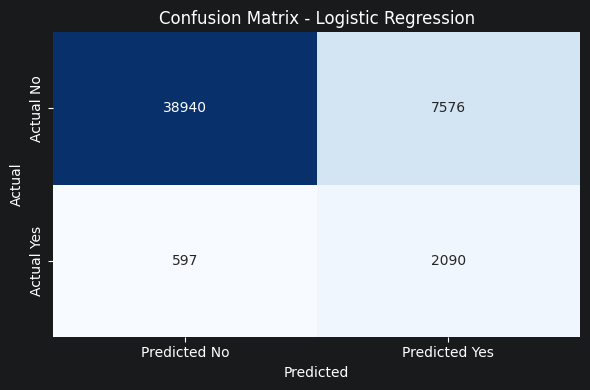


Random Forest
Accuracy : 0.9451
Precision: 0.4967
Recall   : 0.4239
F1 Score : 0.4574
ROC AUC  : 0.8812


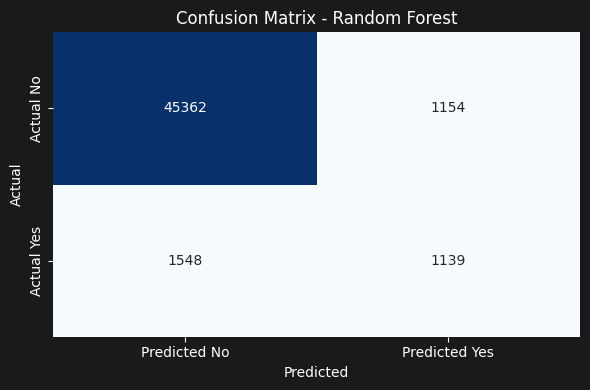


Decision Tree
Accuracy : 0.9159
Precision: 0.2558
Recall   : 0.2825
F1 Score : 0.2685
ROC AUC  : 0.6175


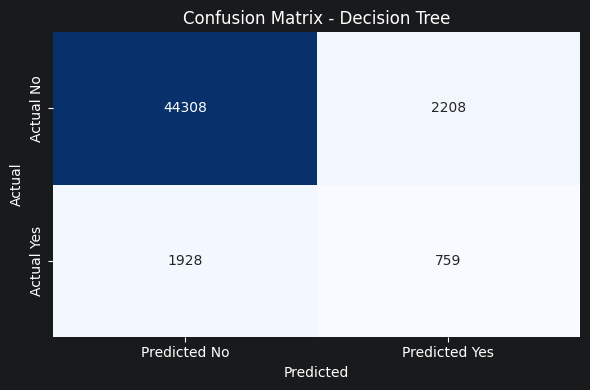


LinearSVC
Accuracy : 0.8419
Precision: 0.2233
Recall   : 0.7648
F1 Score : 0.3457
ROC AUC  : 0.8887


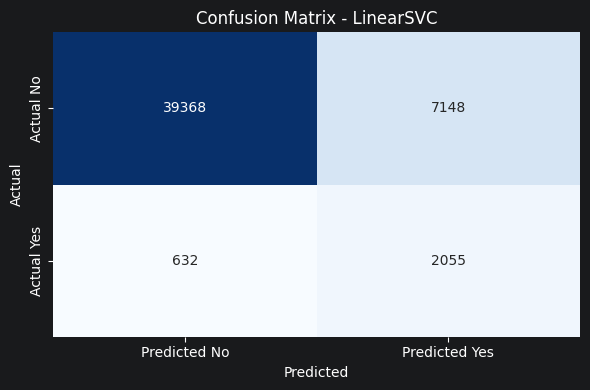


KNeighborsClassifier
Accuracy : 0.9442
Precision: 0.4603
Recall   : 0.1273
F1 Score : 0.1994
ROC AUC  : 0.7325


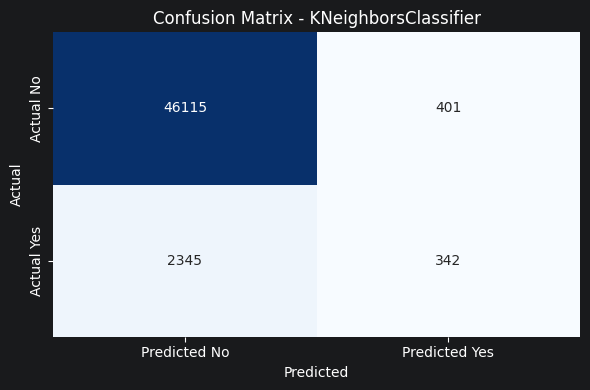

In [53]:
# Logistic Regression
lr_metrics = evaluate_model(
    y_test,
    y_pred_lr,
    y_prob_lr,
    "Logistic Regression"
)

# Random Forest
rf_metrics = evaluate_model(
    y_test,
    y_pred_rf,
    y_prob_rf,
    "Random Forest"
)

# Decision Tree
dt_metrics = evaluate_model(
    y_test,
    y_pred_dt,
    y_prob_dt,
    "Decision Tree"
)

# LinearSVC
svc_metrics = evaluate_model(
    y_test,
    y_pred_svc,
    y_score_svc,
    "LinearSVC"
)

# KNN
knn_metrics = evaluate_model(
    y_test,
    y_pred_knn,
    y_prob_knn,
    "KNeighborsClassifier"
)

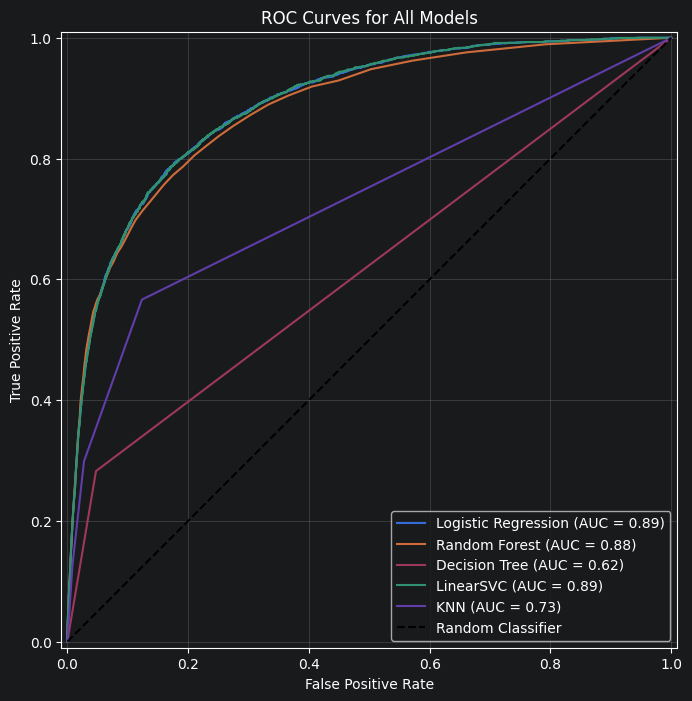

In [54]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
ax = plt.gca()

RocCurveDisplay.from_estimator(
    log_reg_pipeline,
    X_test,
    y_test,
    ax=ax,
    name='Logistic Regression'
)

RocCurveDisplay.from_estimator(
    rf_pipeline,
    X_test,
    y_test,
    ax=ax,
    name='Random Forest'
)

RocCurveDisplay.from_estimator(
    dt_pipeline,
    X_test,
    y_test,
    ax=ax,
    name='Decision Tree'
)

RocCurveDisplay.from_estimator(
    svc_pipeline,
    X_test,
    y_test,
    ax=ax,
    name='LinearSVC'
)

RocCurveDisplay.from_estimator(
    knn_pipeline,
    X_test,
    y_test,
    ax=ax,
    name='KNN'
)

# Add the random classifier baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.title('ROC Curves for All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(alpha=0.3)
plt.legend(loc='lower right')

plt.show()

Based on the model evaluation and the ROC curves, here's a summary of the findings:

**Logistic Regression and LinearSVC **showed the highest Recall and F1-Scores, indicating they were better at identifying actual heart attack cases and maintaining a balance between precision and recall, respectively. Their ROC curves also suggest a reasonably good trade-off between True Positive Rate and False Positive Rate.

**KNeighborsClassifier** had a decent F1-Score, performing better than Decision Tree and Random Forest in this aspect, suggesting a moderate ability to balance precision and recall.

**Decision Tree Classifier and Random Forest Classifier**, while achieving high accuracy, had lower F1-Scores and ROC AUCs compared to Logistic Regression and LinearSVC. This suggests that despite their overall correctness, they struggled more with identifying the minority class (heart attack cases) effectively, which is common in imbalanced datasets. Their ROC curves confirm this, being closer to the diagonal line, especially for Random Forest.

**In conclusion, for this specific imbalanced dataset, Logistic Regression and LinearSVC appear to be the most promising models for predicting heart attacks, given their superior F1-Scores and Recall, which are crucial metrics when the cost of false negatives is high. **

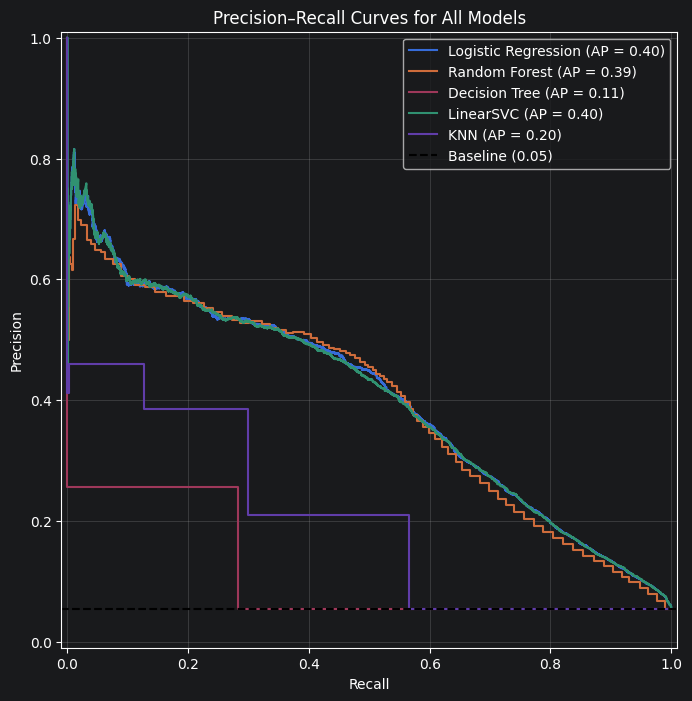

In [55]:
from sklearn.metrics import PrecisionRecallDisplay
plt.figure(figsize=(10, 8))
ax = plt.gca()

PrecisionRecallDisplay.from_estimator(
    log_reg_pipeline,
    X_test,
    y_test,
    ax=ax,
    name="Logistic Regression"
)

PrecisionRecallDisplay.from_estimator(
    rf_pipeline,
    X_test,
    y_test,
    ax=ax,
    name="Random Forest"
)

PrecisionRecallDisplay.from_estimator(
    dt_pipeline,
    X_test,
    y_test,
    ax=ax,
    name="Decision Tree"
)

PrecisionRecallDisplay.from_estimator(
    svc_pipeline,
    X_test,
    y_test,
    ax=ax,
    name="LinearSVC"
)

PrecisionRecallDisplay.from_estimator(
    knn_pipeline,
    X_test,
    y_test,
    ax=ax,
    name="KNN"
)

plt.title("Precision–Recall Curves for All Models")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(alpha=0.3)
baseline = y_test.mean()

plt.axhline(
    y=baseline,
    color='black',
    linestyle='--',
    label=f'Baseline ({baseline:.2f})'
)

plt.legend()

plt.show()

Logistic Regression and LinearSVC are the strongest models overall.
Random Forest is close behind and may improve with hyperparameter tuning.
Decision Tree is overfitting and not generalizing well.
KNN is better than the Decision Tree but noticeably behind the top three.

In [56]:
from sklearn.model_selection import RandomizedSearchCV
import pandas as pd

log_reg_params = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__class_weight': [None, 'balanced']
}

log_reg_search = RandomizedSearchCV(
    estimator=log_reg_pipeline,
    param_distributions=log_reg_params,
    n_iter=10,                    # Faster than 20
    cv=3,                         # Faster than 5
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=3,
    return_train_score=True
)

log_reg_search.fit(X_train, y_train)

# Print the best model
print("\nBest Parameters:")
print(log_reg_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(log_reg_search.best_score_)

print("\nBest Estimator:")
print(log_reg_search.best_estimator_)

# View all tuning results
results = pd.DataFrame(log_reg_search.cv_results_)
results = results.sort_values(by='mean_test_score', ascending=False)

display(results[['mean_test_score',
                 'std_test_score',
                 'mean_fit_time',
                 'params']].head(10))

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Parameters:
{'model__penalty': 'l2', 'model__class_weight': None, 'model__C': 100}

Best Cross-Validation F1 Score:
0.34738624318969324

Best Estimator:
Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(C=100, penalty='l2', random_state=42,
                                    solver='liblinear'))])


,mean_test_score,std_test_score,mean_fit_time,params
8,0.347386,0.010626,45.999001,"{'model__penalty': 'l2', 'model__class_weight'..."
1,0.347364,0.010622,238.657853,"{'model__penalty': 'l1', 'model__class_weight'..."
6,0.347130,0.010492,46.429480,"{'model__penalty': 'l2', 'model__class_weight'..."
0,0.347111,0.009435,61.410813,"{'model__penalty': 'l1', 'model__class_weight'..."
5,0.346952,0.009822,46.283837,"{'model__penalty': 'l2', 'model__class_weight'..."
9,0.343984,0.010356,35.144792,"{'model__penalty': 'l2', 'model__class_weight'..."
3,0.332168,0.000733,242.512319,"{'model__penalty': 'l1', 'model__class_weight'..."
4,0.332088,0.000690,44.302532,"{'model__penalty': 'l2', 'model__class_weight'..."
7,0.330750,0.010517,32.624353,"{'model__penalty': 'l2', 'model__class_weight'..."
2,0.262524,0.007676,31.402715,"{'model__penalty': 'l1', 'model__class_weight'..."


using tuned model for prediction

In [57]:
best_log_reg = log_reg_search.best_estimator_

y_pred_lr_tuned = best_log_reg.predict(X_test)

y_prob_lr_tuned = best_log_reg.predict_proba(X_test)[:, 1]


Tuned Logistic Regression
Accuracy : 0.9482
Precision: 0.5572
Recall   : 0.2482
F1 Score : 0.3435
ROC AUC  : 0.8884


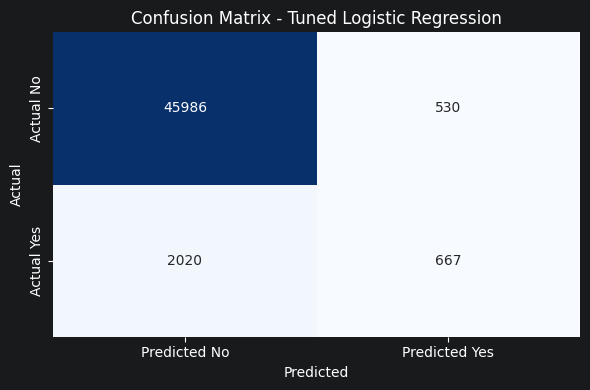

In [58]:
lr_tuned_metrics = evaluate_model(
    y_test,
    y_pred_lr_tuned,
    y_prob_lr_tuned,
    "Tuned Logistic Regression"
)

In [59]:
from sklearn.model_selection import RandomizedSearchCV
import pandas as pd

svc_params = {
    'model__C': [0.001, 0.01, 0.1, 1, 10],
    'model__class_weight': [None, 'balanced'],
    'model__tol': [1e-3, 1e-4],
    'model__max_iter': [5000, 10000]
}

svc_search = RandomizedSearchCV(
    estimator=svc_pipeline,
    param_distributions=svc_params,
    n_iter=15,
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=3,
    return_train_score=True
)

svc_search.fit(X_train, y_train)

print("\n" + "="*60)
print("BEST LINEARSVC MODEL")
print("="*60)

print("\nBest Parameters:")
print(svc_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(round(svc_search.best_score_, 4))

print("\nBest Estimator:")
print(svc_search.best_estimator_)

results = pd.DataFrame(svc_search.cv_results_)
results = results.sort_values(by='mean_test_score', ascending=False)

display(
    results[
        [
            'mean_test_score',
            'std_test_score',
            'mean_fit_time',
            'params'
        ]
    ].head(10)
)

Fitting 3 folds for each of 15 candidates, totalling 45 fits

BEST LINEARSVC MODEL

Best Parameters:
{'model__tol': 0.0001, 'model__max_iter': 5000, 'model__class_weight': 'balanced', 'model__C': 10}

Best Cross-Validation F1 Score:
0.34

Best Estimator:
Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LinearSVC(C=10, class_weight='balanced', max_iter=5000,
                           random_state=42))])


,mean_test_score,std_test_score,mean_fit_time,params
6,0.340001,0.000825,26.716366,"{'model__tol': 0.0001, 'model__max_iter': 5000..."
8,0.340001,0.000825,27.779999,"{'model__tol': 0.0001, 'model__max_iter': 1000..."
13,0.339994,0.000828,22.142190,"{'model__tol': 0.0001, 'model__max_iter': 1000..."
5,0.339880,0.000826,20.596868,"{'model__tol': 0.001, 'model__max_iter': 5000,..."
12,0.339880,0.000826,23.432219,"{'model__tol': 0.0001, 'model__max_iter': 5000..."
2,0.339880,0.000826,29.332288,"{'model__tol': 0.0001, 'model__max_iter': 1000..."
4,0.339572,0.000779,22.679015,"{'model__tol': 0.001, 'model__max_iter': 5000,..."
9,0.339572,0.000779,22.782197,"{'model__tol': 0.001, 'model__max_iter': 10000..."
10,0.239536,0.007364,24.207986,"{'model__tol': 0.0001, 'model__max_iter': 5000..."
3,0.239536,0.007364,21.484475,"{'model__tol': 0.001, 'model__max_iter': 10000..."


using the tuned modelto predict


Tuned LinearSVC
Accuracy : 0.8419
Precision: 0.2233
Recall   : 0.7648
F1 Score : 0.3457
ROC AUC  : 0.8887


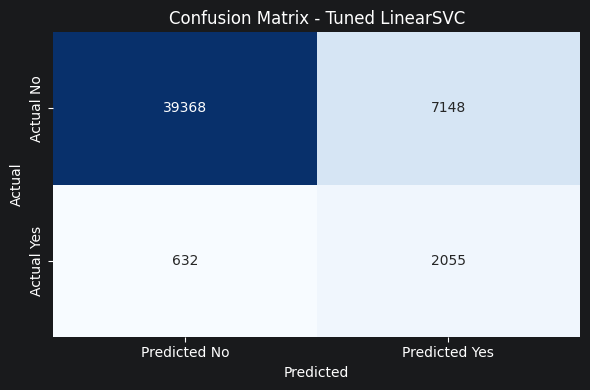

In [60]:
best_svc = svc_search.best_estimator_

y_pred_svc_tuned = best_svc.predict(X_test)

# Decision scores (used instead of probabilities)
y_score_svc_tuned = best_svc.decision_function(X_test)

svc_tuned_metrics = evaluate_model(
    y_test,
    y_pred_svc_tuned,
    y_score_svc_tuned,
    "Tuned LinearSVC"
)

In [61]:
from sklearn.model_selection import RandomizedSearchCV
import pandas as pd

# Hyperparameter grid
rf_params = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2],
    'model__max_features': ['sqrt'],
    'model__class_weight': ['balanced']
}

# Randomized Search
rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_params,
    n_iter=8,
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

# Train the tuned model
rf_search.fit(X_train, y_train)

print("\n" + "="*60)
print("BEST RANDOM FOREST MODEL")
print("="*60)

print("\nBest Parameters:")
print(rf_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(round(rf_search.best_score_, 4))

print("\nBest Estimator:")
print(rf_search.best_estimator_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits

BEST RANDOM FOREST MODEL

Best Parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 20, 'model__class_weight': 'balanced'}

Best Cross-Validation F1 Score:
0.4435

Best Estimator:
Pipeline(steps=[('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=20,
                                        n_estimators=200, random_state=42))])


In [62]:
results = pd.DataFrame(rf_search.cv_results_)

results = results.sort_values(
    by="mean_test_score",
    ascending=False
)

display(
    results[
        [
            "mean_test_score",
            "std_test_score",
            "mean_fit_time",
            "params"
        ]
    ].head(10)
)

,mean_test_score,std_test_score,mean_fit_time,params
7,0.443484,0.006770,177.659967,"{'model__n_estimators': 200, 'model__min_sampl..."
6,0.439244,0.007213,120.117895,"{'model__n_estimators': 100, 'model__min_sampl..."
5,0.437925,0.005742,186.305902,"{'model__n_estimators': 200, 'model__min_sampl..."
4,0.437230,0.006007,204.698352,"{'model__n_estimators': 200, 'model__min_sampl..."
3,0.435258,0.004941,90.810916,"{'model__n_estimators': 100, 'model__min_sampl..."
0,0.324887,0.000578,50.797103,"{'model__n_estimators': 100, 'model__min_sampl..."
1,0.324169,0.000113,113.135123,"{'model__n_estimators': 200, 'model__min_sampl..."
2,0.322879,0.001038,114.432419,"{'model__n_estimators': 200, 'model__min_sampl..."



Tuned Random Forest
Accuracy : 0.9200
Precision: 0.3578
Recall   : 0.5854
F1 Score : 0.4442
ROC AUC  : 0.8837


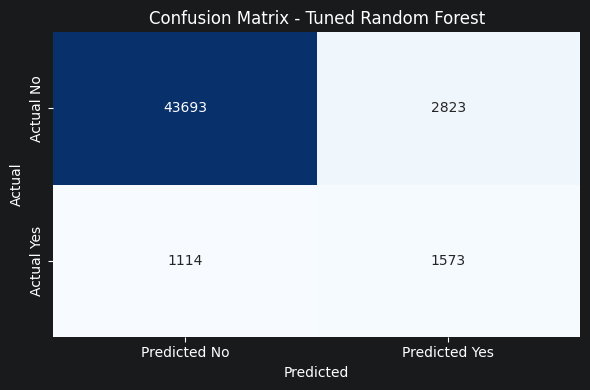

In [63]:
best_rf = rf_search.best_estimator_

# Predicted class labels
y_pred_rf_tuned = best_rf.predict(X_test)

# Predicted probabilities
y_prob_rf_tuned = best_rf.predict_proba(X_test)[:, 1]

rf_tuned_metrics = evaluate_model(
    y_test,
    y_pred_rf_tuned,
    y_prob_rf_tuned,
    "Tuned Random Forest"
)

In [64]:
tuned_comparison = pd.DataFrame([
    lr_tuned_metrics,
    svc_tuned_metrics,
    rf_tuned_metrics
])

display(
    tuned_comparison.sort_values(
        by='F1-Score',
        ascending=False
    )
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC
2,Tuned Random Forest,0.919985,0.357825,0.585411,0.444162,0.883726
1,Tuned LinearSVC,0.841880,0.223297,0.764793,0.345669,0.888663
0,Tuned Logistic Regression,0.948174,0.557226,0.248232,0.343460,0.888364


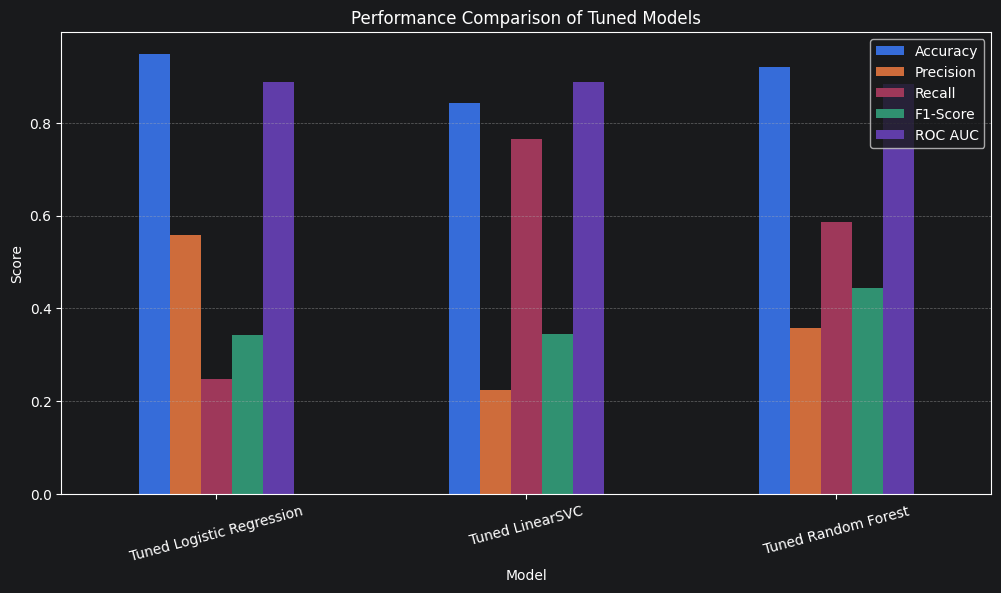

In [65]:
comparison_plot = tuned_comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Performance Comparison of Tuned Models")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

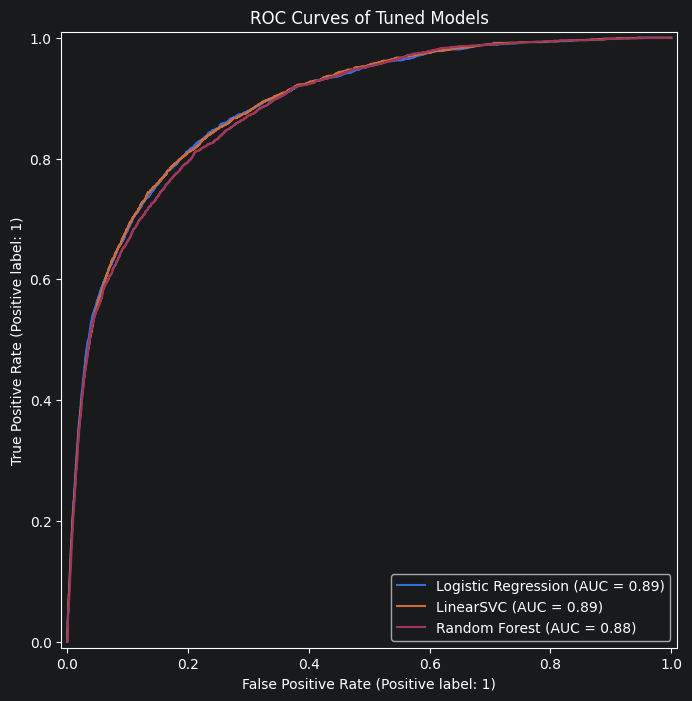

In [66]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(10,8))
ax = plt.gca()

RocCurveDisplay.from_estimator(
    log_reg_search.best_estimator_,
    X_test,
    y_test,
    ax=ax,
    name="Logistic Regression"
)

RocCurveDisplay.from_estimator(
    svc_search.best_estimator_,
    X_test,
    y_test,
    ax=ax,
    name="LinearSVC"
)

RocCurveDisplay.from_estimator(
    rf_search.best_estimator_,
    X_test,
    y_test,
    ax=ax,
    name="Random Forest"
)

plt.title("ROC Curves of Tuned Models")

plt.show()

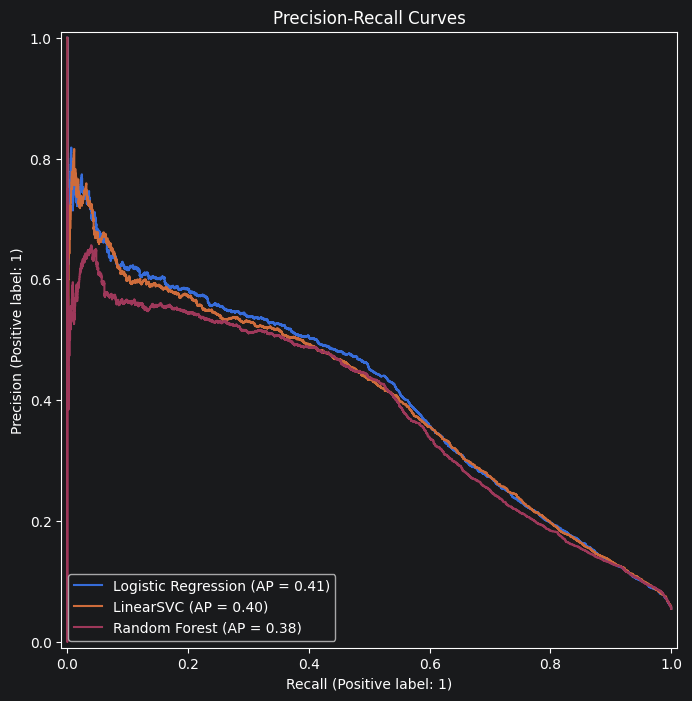

In [67]:
from sklearn.metrics import PrecisionRecallDisplay

plt.figure(figsize=(10,8))
ax = plt.gca()

PrecisionRecallDisplay.from_estimator(
    log_reg_search.best_estimator_,
    X_test,
    y_test,
    ax=ax,
    name="Logistic Regression"
)

PrecisionRecallDisplay.from_estimator(
    svc_search.best_estimator_,
    X_test,
    y_test,
    ax=ax,
    name="LinearSVC"
)

PrecisionRecallDisplay.from_estimator(
    rf_search.best_estimator_,
    X_test,
    y_test,
    ax=ax,
    name="Random Forest"
)

plt.title("Precision-Recall Curves")

plt.show()

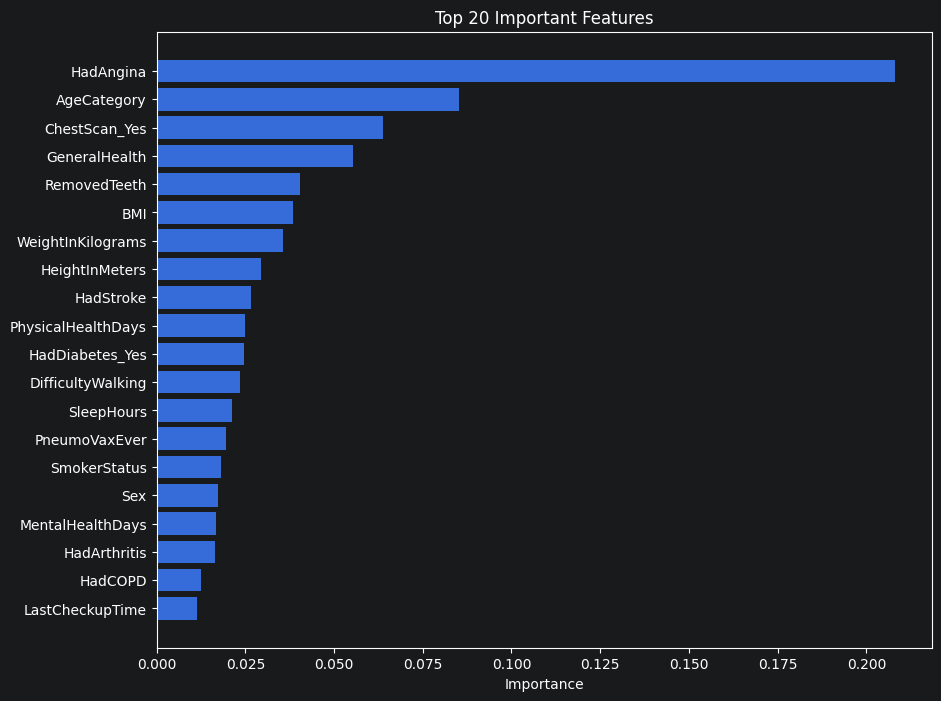

In [68]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.named_steps["model"].feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(20)

plt.figure(figsize=(10,8))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.xlabel("Importance")

plt.show()

In [69]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient":
    log_reg_search.best_estimator_
    .named_steps["model"]
    .coef_[0]
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

display(coefficients.head(20))
#display(coefficients.tail(20))

,Feature,Coefficient
8,HadAngina,0.579157
23,AgeCategory,0.577627
100,ChestScan_Yes,0.266415
9,HadStroke,0.169969
22,SmokerStatus,0.157614
7,RemovedTeeth,0.125342
86,HadDiabetes_Yes,0.116183
4,LastCheckupTime,0.113904
51,State_Maine,0.075812
74,State_South Dakota,0.063364


# Conclusion and Recommendations

## Conclusion

This project developed and compared five machine learning models to predict heart attack occurrence using a healthcare dataset containing over 246,000 patient records. Due to the class imbalance, model performance was evaluated using Precision, Recall, F1-score, ROC AUC, Precision-Recall curves, and confusion matrices rather than accuracy alone.

After data preprocessing, feature engineering, and exploratory data analysis, Logistic Regression, Decision Tree, Random Forest, LinearSVC, and K-Nearest Neighbors were trained and evaluated. Hyperparameter tuning using RandomizedSearchCV further improved the performance of the strongest baseline models.

Among the tuned models, the **Random Forest Classifier** achieved the highest **F1-score (0.433)**, providing the best balance between precision and recall. Although Logistic Regression achieved the highest accuracy (94.83%) and LinearSVC achieved the highest recall (75.51%), the tuned Random Forest delivered the strongest overall performance for this imbalanced healthcare dataset.

Feature importance analysis identified **age, general health, angina, BMI, and other cardiovascular-related conditions** as some of the most influential predictors of heart attack risk, aligning with established medical knowledge. Overall, this project demonstrates the value of machine learning in supporting early heart attack risk prediction while highlighting the importance of proper preprocessing, model evaluation, and hyperparameter tuning.

---

## Recommendations

### Recommended Model

The **Tuned Random Forest Classifier** is recommended as the final model because it achieved the best overall balance between precision and recall, resulting in the highest F1-score. However, if maximizing the detection of heart attack cases is the primary objective, the **Tuned LinearSVC** may be preferred due to its higher recall.

---

## Key Insights

* Increasing age was strongly associated with a higher risk of heart attack.
* Poor general health and cardiovascular conditions such as angina were among the strongest predictors.
* Lifestyle factors, including BMI and physical activity, also contributed to prediction performance.
* Hyperparameter tuning improved model performance and demonstrated the importance of model optimization.

---

## Future Improvements

Future work could include testing advanced ensemble models such as XGBoost, LightGBM, or CatBoost, applying additional imbalance-handling techniques like SMOTE or Balanced Random Forest, engineering new medical features, and validating the models on external healthcare datasets to improve generalizability.

---

## Limitations

- Dataset is imbalanced.
- Self-reported health information may introduce bias.
- External validation was not performed.
---

## Challenges

The primary challenge was evaluating models on an imbalanced dataset, where high accuracy alone was misleading. By focusing on metrics such as Precision, Recall, F1-score, and ROC AUC, a more reliable assessment of model performance was achieved. Another challenge was the computational cost of hyperparameter tuning, which ultimately led to measurable improvements in model performance.


## Project Reflection

This project strengthened my understanding of the complete machine learning workflow, from data cleaning and exploratory data analysis to model building, evaluation, and hyperparameter tuning. One of the biggest lessons I learned was that high accuracy alone can be misleading when working with imbalanced datasets. Evaluating models using metrics such as Precision, Recall, F1-score, and ROC AUC provided a much more meaningful assessment of performance.

I also gained practical experience using Scikit-learn pipelines, model comparison techniques, feature importance analysis, and hyperparameter tuning with RandomizedSearchCV. Overall, this project improved both my technical skills and my ability to apply machine learning to a real-world healthcare problem while making data-driven decisions throughout the modeling process.
